## Implementation of Quantum Fourier Transform (QFT) Addition

In [3]:
# !pip install qiskit_aer
%matplotlib inline

import sys
sys.path.append("../src")

from qiskit import QuantumRegister, QuantumCircuit, ClassicalRegister
from qiskit import transpile
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
import math
import numpy as np
from qiskit.synthesis.qft import synth_qft_full
from qiskit.circuit.library import DraperQFTAdder

The QFT adder implements

$$
\lvert a\rangle \,\lvert b\rangle 
\;\longmapsto\;
\lvert a\rangle \,\lvert (a + b) \!\!\!\pmod{2^{n}}\rangle.
$$

The circuit works in three steps:

1. Apply the QFT to the b-register to encode b in phases:
   

$$
\lvert a\rangle \,\lvert b\rangle \;\longmapsto\; \lvert a\rangle \,\mathrm{QFT}\lvert b\rangle.
$$



2. Use controlled phase rotations from a-regisger on the QFT‑encoded b-register to add a in the phase domain:

$$
\lvert a\rangle \,\mathrm{QFT}\lvert b\rangle \;\longmapsto\; \lvert a\rangle \,\mathrm{QFT}\lvert a + b \rangle.
$$

3. Apply the inverse QFT to recover the sum in the computational basis:
   
$$
\lvert a\rangle \,\mathrm{QFT}\lvert a + b \rangle \;\longmapsto\; \lvert a\rangle \,\lvert (a + b) \!\!\!\pmod{2^{n}}\rangle
$$

## Setup in Qiskit - Starting point for reconciliation

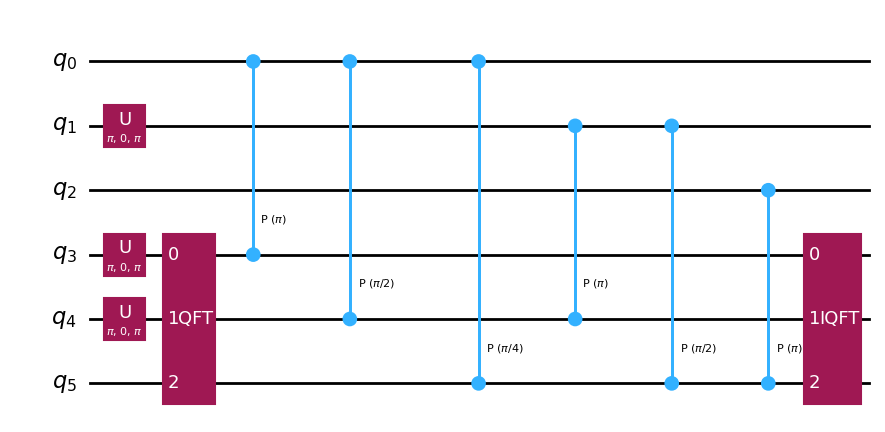

In [58]:
n = 3  # number of qubits

a_val = 2
b_val = 3

adder = DraperQFTAdder(num_state_qubits=n, kind='fixed')   # modulo 2^n addition

qc = QuantumCircuit(2*n)

# Load a and b
for i in range(n):
    if (a_val >> i) & 1:
        qc.x(i)
    if (b_val >> i) & 1:
        qc.x(n + i)
        
qc.append(adder, range(2*n))

qc.decompose().decompose().draw('mpl')

## Individual Gate implementation of the QFT Addition

In [59]:
def qft_gate_3():
    qc = QuantumCircuit(3, name="QFT3")

    qc.h(2)
    qc.cp(np.pi/2, 2, 1)
    qc.cp(np.pi/4, 2, 0)

    qc.h(1)
    qc.cp(np.pi/2, 1, 0)

    qc.h(0)

    #qc.swap(0, 2)

    return qc.to_gate()

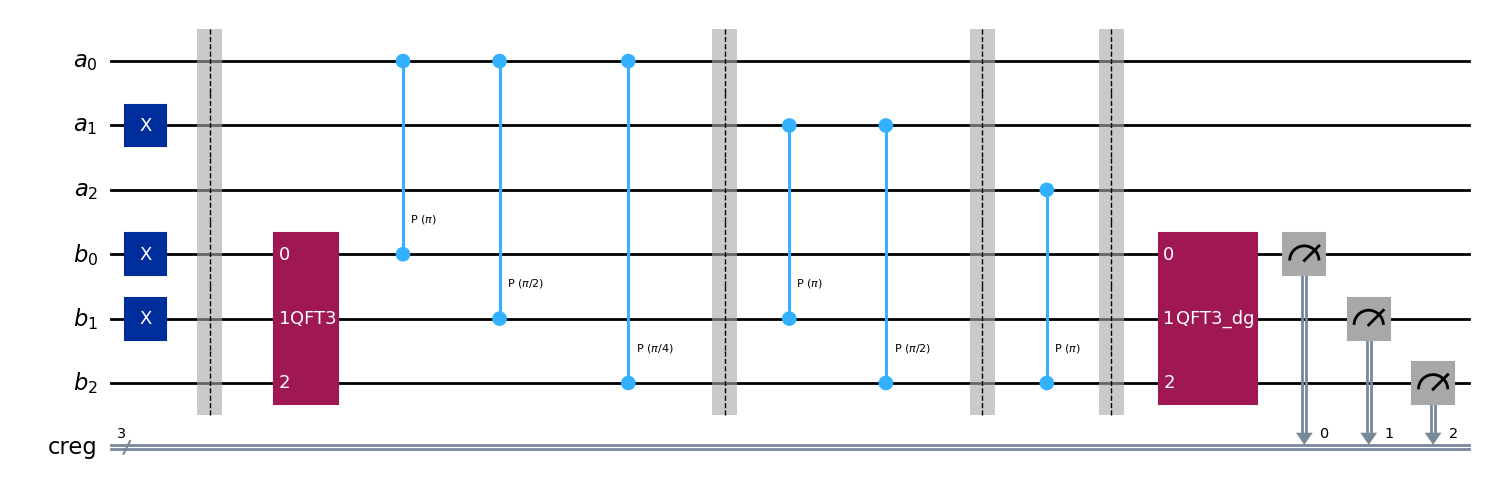

In [61]:
n = 3 # number of qubits

a_val = 2
b_val = 3

a = QuantumRegister(n, 'a') 
b = QuantumRegister(n, 'b') 
creg = ClassicalRegister(len(b), 'creg')

qc = QuantumCircuit(a, b, creg) 

# Prepare the circuit
for i in range(n):
    if (a_val >> i) & 1:
        qc.x(a[i])    
    if (b_val >> i) & 1:
        qc.x(b[i])

qc.barrier()

# Define QFT and IQFT (inverse QFT)
qft3 = qft_gate_3() 
iqft3 = qft3.inverse()

# Apply QFT
qc.append(qft3, b)

# Adding a to b (correct)
for i in range(n):
    for k in range(n - i):
        angle = np.pi / 2**k
        qc.cp(angle, a[i], b[i + k])
    qc.barrier()

# Apply IQFT
qc.append(iqft3, b)

# Measure results
qc.measure(b, creg)

qc.draw('mpl')

In [62]:
sim = AerSimulator(method="matrix_product_state")

tqc = transpile(qc, sim)

nbr_shots = 2**12
result = sim.run(tqc, shots=nbr_shots).result()
counts = result.get_counts()

counts

{'101': 4096}

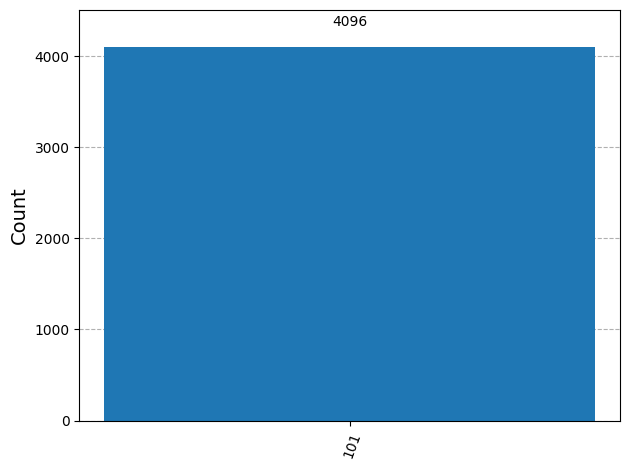

In [63]:
plot_histogram(counts)

Expected result is 

$$
\lvert 2\rangle 3\rangle 
\longmapsto\;
\lvert2\rangle \lvert(2 + 3) \pmod{2^{3}}\rangle  
=\lvert2\rangle \lvert5 \pmod{2^{3}}\rangle  
=\lvert2\rangle \lvert5 \rangle  
=\lvert010\rangle \lvert101 \rangle  
$$

which got confirmed.

## Wavefunction / Dirac Notation

### Initial circuit

Note that the qubit order in a circuit in Qiskit $|q0,q1,q2\rangle$ is different from the textbook notation $|q2,q1,q0\rangle$.

The qubit on the bottom of the circuit is the MSB and the upper qubit is the LSB. We will use the textbook notation here.

We start with qubits $a$ and $b$ in the intial state $|000\rangle$

$$
|\psi_0\rangle = |000\rangle_{a} \otimes |000\rangle_{b}
$$

## Set $a=2$ and $b=3$

$$
\lvert\psi_1\rangle = \lvert010\rangle_{a} \otimes \lvert011\rangle_{b}
$$

### Apply QFT 

For our example with 3 qubits for each $a$ and $b$ and $N=2^n=2^3=8$ and $b=3$ applying

$$
\mathrm{QFT}_N\,|x\rangle
=
\bigotimes_{j=0}^{2}
\frac{1}{\sqrt{2}}
\left(
|0\rangle
+
e^{\,2\pi i\, x / 2^{\,j+1}}\,
|1\rangle
\right)_{q_j}
$$

we get

$$
\mathrm{QFT}_8\,|3\rangle
=
\frac{1}{\sqrt{2}}
\left(
|0\rangle
+
e^{\,2\pi i\, 3 / 2}\,
|1\rangle
\right)_{b_0}
\bigotimes
\frac{1}{\sqrt{2}}
\left(
|0\rangle
+
e^{\,2\pi i\, 3 / 4}\,
|1\rangle
\right)_{b_1}
\bigotimes
\frac{1}{\sqrt{2}}
\left(
|0\rangle
+
e^{\,2\pi i\, 3 / 2^{\,3}}\,
|1\rangle
\right)_{b_2}
$$

Our full state becomes

$$
\lvert\psi_2\rangle = 
\lvert010\rangle_{a} \otimes
\frac{1}{\sqrt{2}}
\left(
|0\rangle
+
e^{\,2\pi i\, 3 / 2}\,
|1\rangle
\right)_{b_0}
\bigotimes
\frac{1}{\sqrt{2}}
\left(
|0\rangle
+
e^{\,2\pi i\, 3 / 4}\,
|1\rangle
\right)_{b_1}
\bigotimes
\frac{1}{\sqrt{2}}
\left(
|0\rangle
+
e^{\,2\pi i\, 3 / 2^{\,3}}\,
|1\rangle
\right)_{b_2}
$$

### Apply controlled phase gates $CR_1, CR_2, CR_3$ from $a_0$ to $b_0, b_1, b_2$ 

With phases $e^{2\pi\,i/2^k}$

- $b_0: \theta=2\pi\,i/2^1=2\pi\,i/2$
- $b_1: \theta=2\pi\,i/2^2=2\pi\,i/4$
- $b_2: \theta=2\pi\,i/2^3=2\pi\,i/8$

We start with the first one. The controlled phase gate $R_1$ applies $e^{i \pi}=e^{2\pi i \cdot \frac{1}{2}}$ if both $a_0$ and $b_0$ are in $\lvert 1 \rangle_{a_0}$ and $\lvert 1 \rangle_{b_0}$ state. 

But as in this specific example $a_0=\lvert 0 \rangle$, the phase gate has no effect and the wave function remains unchanged.

$$
\lvert\psi_3\rangle = 
\lvert010\rangle_{a} \otimes
\frac{1}{\sqrt{2}}
\left(
|0\rangle
+
e^{\,2\pi i\, 3 / 2}\,
|1\rangle
\right)_{b_0}
\bigotimes
\frac{1}{\sqrt{2}}
\left(
|0\rangle
+
e^{\,2\pi i\, 3 / 4}\,
|1\rangle
\right)_{b_1}
\bigotimes
\frac{1}{\sqrt{2}}
\left(
|0\rangle
+
e^{\,2\pi i\, 3 / 8}\,
|1\rangle
\right)_{b_2}
$$

The same is true for the next 2 controlled phase gates.

### Apply controlled phase gates $CR_1, CR_2$ from $a_1$ to $b_1, b_2$ 

We apply phases $\theta$ in $e^{i \theta}$

- $b_1 : \theta=2\pi\,/2^1=2\pi\,/2=2\pi\,2/4$
- $b_2 : \theta=2\pi\,/2^2=2\pi\,/4=2\pi\,2/8$ to $b_2$

as $a_1=\lvert 1 \rangle$

$$
\lvert\psi_4\rangle = 
\lvert010\rangle_{a} \otimes
\frac{1}{\sqrt{2}}
\left(
|0\rangle
+
e^{\,2\pi i\, 3 / 2}\,
|1\rangle
\right)_{b_0}
\bigotimes
\frac{1}{\sqrt{2}}
\left(
|0\rangle
+
e^{\,2\pi i\, 2 / 4}\, e^{\,2\pi i\, 3 / 4}\,
|1\rangle
\right)_{b_1}
\bigotimes
\frac{1}{\sqrt{2}}
\left(
|0\rangle
+
e^{\,2\pi i\, 2 / 8}\, e^{\,2\pi i\, 3 / 8}\,
|1\rangle
\right)_{b_2}
$$

### Apply controlled phase gates $CR_1$ from $a_2$ to $b_2$ 

With phases 

- $b_2 : \theta=2\pi\,/2^1=2\pi\,/2=2\pi\,2/4$

has again no effect since $a_2=0$ in our specific example, and the final result is therefore

$$
\lvert\psi_5\rangle = 
\lvert010\rangle_{a} \otimes
\frac{1}{\sqrt{2}}
\left(
|0\rangle
+
e^{\,2\pi i\, 3 / 2}\,
|1\rangle
\right)_{b_0}
\bigotimes
\frac{1}{\sqrt{2}}
\left(
|0\rangle
+
e^{\,2\pi i\, 2 / 4}\, e^{\,2\pi i\, 3 / 4}\,
|1\rangle
\right)_{b_1}
\bigotimes
\frac{1}{\sqrt{2}}
\left(
|0\rangle
+
e^{\,2\pi i\, 2 / 8}\, e^{\,2\pi i\, 3 / 8}\,
|1\rangle
\right)_{b_2}
$$

Note that $e^{\,2\pi i\, 3 / 2}\,=e^{\,2\pi i\, 5 / 2}\,$, since 

$$
\frac{3}{2} \equiv \frac{1}{2} \pmod{1}, \qquad
\frac{5}{2} \equiv \frac{1}{2} \pmod{1}.
$$

Imagine a circle and you can go half circles (a full circle is $2 \pi$). Whether you go 3 half-circles or 5 half-circles, you will always end up at $\pi$.

Now we can write

$$
\lvert\psi_5\rangle = 
\lvert010\rangle_{a} \otimes
\frac{1}{\sqrt{2}}
\left(
|0\rangle
+
e^{\,2\pi i\, 5 / 2}\,
|1\rangle
\right)_{b_0}
\bigotimes
\frac{1}{\sqrt{2}}
\left(
|0\rangle
+
e^{\,2\pi i\, 2 / 4}\, e^{\,2\pi i\, 3 / 4}\,
|1\rangle
\right)_{b_1}
\bigotimes
\frac{1}{\sqrt{2}}
\left(
|0\rangle
+
e^{\,2\pi i\, 2 / 8}\, e^{\,2\pi i\, 3 / 8}\,
|1\rangle
\right)_{b_2}
$$

$$
\lvert\psi_5\rangle = 
\lvert010\rangle_{a} \otimes
\frac{1}{\sqrt{2}}
\left(
|0\rangle
+
e^{\,2\pi i\, (2+3) / 2}\,
|1\rangle
\right)_{b_0}
\bigotimes
\frac{1}{\sqrt{2}}
\left(
|0\rangle
+
e^{\,2\pi i\, (2+3) / 4}\,
|1\rangle
\right)_{b_1}
\bigotimes
\frac{1}{\sqrt{2}}
\left(
|0\rangle
+
e^{\,2\pi i\, (2+3) / 8}\,
|1\rangle
\right)_{b_2}
$$

and further simplify to

$$
\lvert\psi_5\rangle = 
\lvert010\rangle_{a} \otimes
\frac{1}{\sqrt{2}}
\left(
|0\rangle
+
e^{\,2\pi i\, 5 / 2}\,
|1\rangle
\right)_{b_0}
\bigotimes
\frac{1}{\sqrt{2}}
\left(
|0\rangle
+
e^{\,2\pi i\, 5 / 4}\,
|1\rangle
\right)_{b_1}
\bigotimes
\frac{1}{\sqrt{2}}
\left(
|0\rangle
+
e^{\,2\pi i\, 5 / 8}\,
|1\rangle
\right)_{b_2}
$$

Now we see the result (2+3)=5 exactly in the exponent.

Applying the Inverse QFT yields as expected the following result in the computational basis:

$$
\lvert\psi_6\rangle = \lvert010\rangle_{a} \otimes \lvert101\rangle_{b}
$$

$$
\lvert\psi_6\rangle = \lvert2\rangle_{a} \otimes \lvert5\rangle_{b}
$$

Next steps:

- Extend the algorithm for a QFT modular adder
- write the logic for the general case (a+b)